# plotting dpCO$_2$ vs fixedCO$_2$ GWP20 / 100 values [metric calculated with the updated ModuleC]

- loads the two excel files (calculated with moduleC) 
- forward-fills `SSP` and `ModelYear`,
- filters the requested SSPs, model years, and horizons,
- builds a 2×3 superplot for CO$_2$, CH$_4$, and N$_2$O.

Marker color encodes **SSP** and fill level encodes **ModelYear**:
- open marker = MY2030
- light fill = MY2040
- solid fill = MY2050

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

In [42]:
# -----------------------------
# inputs
# -----------------------------
DP_FILE = Path(r'../AGWPCO2_dp_approach/output_dpGWP_dpCO2_modC/dpGWP_dpCO2_CO2CH4N2O_modC.xlsx')
FIXED_FILE = Path(r'../AGWPCO2_fixed_approach/output_dpGWP_fixedCO2_modC/dpGWP_fixedCO2_CO2CH4N2O_modC.xlsx')

SELECTED_SSPS = ['119', '126', '245', '434', '585']
SELECTED_MODEL_YEARS = [ 2030, 2040, 2050]
TARGET_YEARS = [20, 100]

In [47]:


# SSP palette for future use
SSP_COLORS = {
    '119': '#43dde6',
    '126': '#00a896',
    '245': '#364f6b',
    '370': '#7b2cbf',
    '434': '#f4a261',
    '460': '#e9c46a',
    '534': '#2a9d8f',
    '585': '#fc5185',
}

MARKER_MAP = {
    '119': 'p',
    '126': '^',
    '245': 's',
    '370': 'v',
    '434': 'o',
    '460': 'P',
    '534': '*',
    '585': 'D',
}


In [48]:
def load_metric_table(path: Path) -> pd.DataFrame:
    df = pd.read_excel(path)
    df[['SSP', 'ModelYear']] = df[['SSP', 'ModelYear']].ffill()
    df['SSP'] = df['SSP'].astype(int).astype(str)
    df['ModelYear'] = df['ModelYear'].astype(int)
    return df

def blend_with_white(color: str, alpha_to_white: float = 0.45):
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    return tuple((1 - alpha_to_white) * rgb + alpha_to_white * white)



def get_axis_limits(values, pad_frac: float = 0.08, min_span: float = 0.0):
    values = np.asarray(values, dtype=float)
    vmin = float(np.min(values))
    vmax = float(np.max(values))

    span = vmax - vmin
    if np.isclose(span, 0):
        span = max(abs(vmin) * 0.05, 0.1, min_span)
        return vmin - span / 2, vmax + span / 2

    span = max(span, min_span)
    pad = span * pad_frac
    center = (vmin + vmax) / 2
    half = span / 2 + pad
    return center - half, center + half

def panel_limits(df: pd.DataFrame, gas: str):
    x = df[f"{gas}_dp"].to_numpy()
    y = df[f"{gas}_fixed"].to_numpy()
    all_vals = np.r_[x, y]

    lo, hi = get_axis_limits(all_vals, pad_frac=0.08)
    return (lo, hi), (lo, hi)

In [49]:
dp = load_metric_table(DP_FILE)
fixed = load_metric_table(FIXED_FILE)
merged = dp.merge(fixed, on=['SSP', 'ModelYear', 'Year'], suffixes=('_dp', '_fixed'))

plot_df = merged[
    merged['SSP'].isin(SELECTED_SSPS)
    & merged['ModelYear'].isin(SELECTED_MODEL_YEARS)
    & merged['Year'].isin(TARGET_YEARS)
].copy()

display(plot_df[['SSP', 'ModelYear', 'Year', 'CO2_GWP_dp', 'CO2_GWP_fixed', 'CH4_GWP_dp', 'CH4_GWP_fixed', 'N2O_GWP_dp', 'N2O_GWP_fixed']])

,SSP,ModelYear,Year,CO2_GWP_dp,CO2_GWP_fixed,CH4_GWP_dp,CH4_GWP_fixed,N2O_GWP_dp,N2O_GWP_fixed
121,119,2040,20,1,0.973543,96.204022,91.993583,210.118052,201.840383
201,119,2040,100,1,0.993256,29.862711,29.724466,180.311438,177.222163
222,119,2050,20,1,0.974599,97.530953,93.359489,205.384429,197.150047
302,119,2050,100,1,0.982755,30.122859,29.775975,177.166581,172.729300
424,126,2040,20,1,0.959814,94.352633,88.809078,214.376079,202.734690
504,126,2040,100,1,1.014692,28.070516,28.608028,177.285922,178.036441
525,126,2050,20,1,0.941246,97.696635,90.349003,213.923885,198.804400
605,126,2050,100,1,0.983203,29.168362,28.785533,178.988939,174.201950
727,245,2040,20,1,0.952529,95.828814,89.574820,219.124170,205.598509
807,245,2040,100,1,1.107599,27.773668,30.733670,160.574607,176.170695


Saved figure to: gwp20-100_dp_vs_fixed_CO2.png


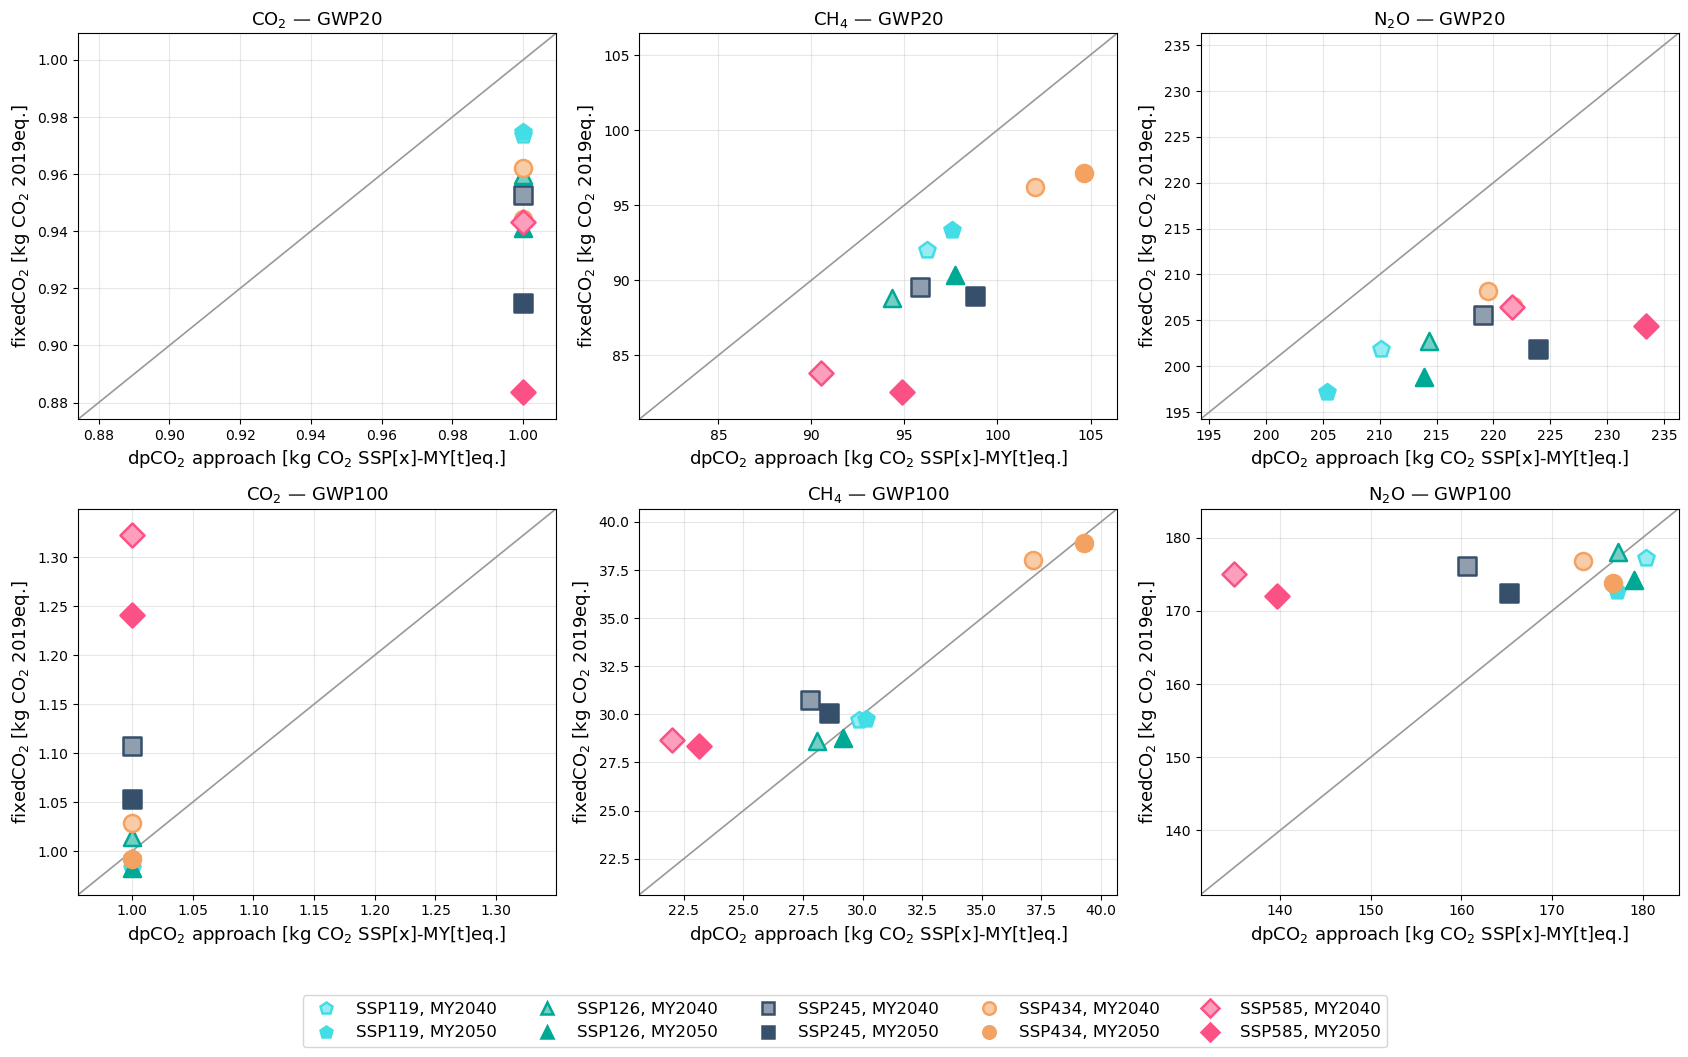

In [50]:
gas_title = {
    'CO2_GWP': 'CO$_2$',
    'CH4_GWP': 'CH$_4$',
    'N2O_GWP': 'N$_2$O',
}

fig, axes = plt.subplots(2, 3, figsize=(17, 10.5))
gas_order = ['CO2_GWP', 'CH4_GWP', 'N2O_GWP']

for row_i, horizon in enumerate(TARGET_YEARS):
    d_year = plot_df[plot_df['Year'] == horizon].copy()

    for col_i, gas in enumerate(gas_order):
        ax = axes[row_i, col_i]
        d_gas = d_year[['SSP', 'ModelYear', f'{gas}_dp', f'{gas}_fixed']].copy()

#        xlim, ylim = panel_limits(d_gas, gas, horizon)
        xlim, ylim = panel_limits(d_gas, gas)
        diag_lo = max(xlim[0], ylim[0])
        diag_hi = min(xlim[1], ylim[1])
        ax.plot([diag_lo, diag_hi], [diag_lo, diag_hi], color='0.6', linewidth=1.2)

        for _, row in d_gas.iterrows():
            ssp = row['SSP']
            my = int(row['ModelYear'])
            color = SSP_COLORS.get(ssp, '#444444')
            marker = MARKER_MAP.get(ssp, 'o')

            if my == 2030:
                face = 'white'
            elif my == 2040:
                face = blend_with_white(color, 0.45)
            else:
                face = color

            ax.scatter(
                row[f'{gas}_dp'],
                row[f'{gas}_fixed'],
                marker=marker,
                s=150,
                facecolors=face,
                edgecolors=color,
                linewidths=1.8,
                zorder=3,
            )

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.grid(True, alpha=0.3)
        ax.set_title(f"{gas_title[gas]} — GWP{horizon}", fontsize=13)
        ax.set_xlabel(f'dpCO$_2$ approach [kg CO$_2$ SSP[x]-MY[t]eq.]', fontsize = 13)
        ax.set_ylabel(f'fixedCO$_2$ [kg CO$_2$ 2019eq.]', fontsize = 13)



legend_handles = []
# build column-wise: each SSP is one column, MYs stacked as rows
for ssp in SELECTED_SSPS:
    color = SSP_COLORS.get(ssp, "#444444")
    marker = MARKER_MAP.get(ssp, "o")

    for my in SELECTED_MODEL_YEARS:
        if my == 2030:
            face = "white"
        elif my == 2040:
            face = blend_with_white(color, 0.45)
        else:
            face = color

        legend_handles.append(
            Line2D(
                [0], [0],
                marker=marker,
                linestyle="None",
                markerfacecolor=face,
                markeredgecolor=color,
                markeredgewidth=1.8,
                markersize=9,
                label=f"SSP{ssp}, MY{my}",
            )
        )

ncol_legend = len(SELECTED_SSPS)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=ncol_legend,
    frameon=True,
    bbox_to_anchor=(0.5, -0.01),
    fontsize=12,
)

fig.tight_layout(rect=[0, 0.08, 1, 1])


output_path =  "gwp20-100_dp_vs_fixed_CO2.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")

plt.show()